# 08 Workflow Patterns & Agents

By the end you can build chaining, parallel Send, routing, orchestrator-worker, and evaluator loops, when parent and child state differ, wrap the subgraph.


Set up the project path and reload shared helpers from this repo.


In [1]:
import sys
import importlib
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "shared").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

# Pick up edits to shared/ without a full kernel restart (re-run this cell)
for _name in (
    "shared.dataflow",
    "shared.notebook_display",
    "shared.llm",
    "shared.bootcamp_fixtures",
):
    importlib.reload(importlib.import_module(_name))

print(f"Project root: {ROOT}")


c:\Users\Azooo\langchain-bootcamp\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\Azooo\langchain-bootcamp


Verify DeepSeek credentials before running LangGraph cells.


In [2]:
import os

def env_status():
    keys = {
        "DEEPSEEK_API_KEY": bool(os.getenv("DEEPSEEK_API_KEY")),
        "DEEPSEEK_MODEL": os.getenv("DEEPSEEK_MODEL", "deepseek-v4-flash"),
        "LLM_PROVIDER": os.getenv("LLM_PROVIDER", "deepseek"),
        "TAVILY_API_KEY": bool(os.getenv("TAVILY_API_KEY")),
        "LANGSMITH_API_KEY": bool(os.getenv("LANGSMITH_API_KEY")),
    }
    for k, v in keys.items():
        print(f"{k}: {v}")
    return keys

ENV = env_status()


DEEPSEEK_API_KEY: True
DEEPSEEK_MODEL: deepseek-v4-flash
LLM_PROVIDER: deepseek
TAVILY_API_KEY: True
LANGSMITH_API_KEY: True


Load the chat model helper used by live cells below.


In [3]:
import os
from shared.llm import get_model

def require_llm():
    return get_model()


Fan out with Send: one orchestrator spawns visa, weather, and activities workers. Annotated list reducers merge notes, build parallel_graph here.


In [8]:
import operator
from typing import Annotated, TypedDict
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from shared.llm import get_model

model = get_model()
RESEARCH_SYSTEM = "You are a travel research assistant. One factual sentence per task."

class ParallelResearch(TypedDict):
    destination: str
    tasks: list[str]
    notes: Annotated[list[str], operator.add]
    task: str

def fan_out(state: ParallelResearch):
    return [Send("research_worker", {"task": t, "destination": state["destination"], "tasks":state["tasks"], "notes": [], "task":t}) for t in state["tasks"]]

def research_worker(state: ParallelResearch):
    note = model.invoke([
        SystemMessage(content=RESEARCH_SYSTEM),
        HumanMessage(content=f"Task: {state['task']}\nDestination: {state['destination']}"),
    ]).content
    return {"notes": [str(note).strip()]}

g = StateGraph(ParallelResearch)
g.add_node("research_worker", research_worker)
g.add_conditional_edges(START, fan_out, ["research_worker"])
g.add_edge("research_worker", END)
parallel_graph = g.compile()


Visualize parallel_graph: one START fans to multiple worker paths. That fan-out shape is parallelization in LangGraph.


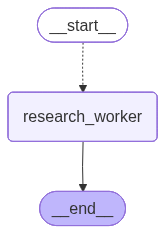

In [ ]:
from IPython.display import Image, display 
display(Image(parallel_graph.get_graph().draw_mermaid_png()))


Run parallel workers for Lisbon. Notice fan-out tasks printed first, then three merged notes in final state, each worker returned a one-item list on purpose.


In [11]:
from shared.dataflow import preview, print_dataflow, print_agent_dataflow, print_final_state
parallel_inputs = {
    "destination": "Lisbon",
    "tasks": ["visa", "weather", "activities"],
    "notes": [],
    "task": "",
}
print(f"fan-out tasks: {parallel_inputs['tasks']}")
print_dataflow(parallel_graph, parallel_inputs)


fan-out tasks: ['visa', 'weather', 'activities']
DATAFLOW
0. input: {'destination': 'Lisbon', 'tasks': ['visa', 'weather', 'activities'], 'notes': [], 'task': ''}
1. research_worker: {'notes': "['Lisbon experiences a Mediterranean climate with mild, rainy winters and warm, dry summers, averaging around 290 sunny days per year.']"}
2. research_worker: {'notes': "['Portugal requires US citizens to have a valid passport for stays up to 90 days, but no visa is needed for tourism or business.']"}
3. research_worker: {'notes': "['Lisbon offers scenic tram rides on the historic Line 28 through the Alfama district.']"}
4. final: {'destination': 'Lisbon', 'tasks': ['visa', 'weather', 'activities'], 'notes': ['Portugal requires US citizens to have a valid passport for stays up to 90 days, but no visa is need...


{'destination': 'Lisbon',
 'tasks': ['visa', 'weather', 'activities'],
 'notes': ['Portugal requires US citizens to have a valid passport for stays up to 90 days, but no visa is needed for tourism or business.',
  'Lisbon experiences a Mediterranean climate with mild, rainy winters and warm, dry summers, averaging around 290 sunny days per year.',
  'Lisbon offers scenic tram rides on the historic Line 28 through the Alfama district.'],
 'task': ''}

Route with structured pick_route + specialist nodes (docs, booking, urgent). Three different requests should hit three different handlers in DATAFLOW.


In [12]:
from typing import Literal, TypedDict
from pydantic import BaseModel
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from shared.llm import get_model

model = get_model()

class RouteChoice(BaseModel):
    route: Literal["docs", "booking", "human_review", "general"]

router = model.with_structured_output(RouteChoice, method="function_calling")
ROUTER_SYSTEM = "You route travel support requests to the correct specialist path."
SPECIALIST_PROMPTS = {
    "docs": "You are the docs/visa specialist.",
    "booking": "You are the booking specialist.",
    "human_review": "You are escalating to a human agent.",
    "general": "You are a general travel support agent.",
}

class RoutePlan(TypedDict):
    request: str
    route: str
    answer: str

def pick_route(state: RoutePlan):
    choice = router.invoke([
        SystemMessage(content=ROUTER_SYSTEM),
        HumanMessage(content=state["request"]),
    ])
    return Command(goto=choice.route)

def make_handler(route: str):
    def handler(state: RoutePlan):
        text = model.invoke([
            SystemMessage(content=SPECIALIST_PROMPTS[route] + " Reply in one sentence."),
            HumanMessage(content=state["request"]),
        ]).content
        return {"route": route, "answer": str(text).strip()}
    return handler

g = StateGraph(RoutePlan)
g.add_node("pick_route", pick_route)
for name in ("docs", "booking", "human_review", "general"):
    g.add_node(name, make_handler(name))
g.add_edge(START, "pick_route")
for name in ("docs", "booking", "human_review", "general"):
    g.add_edge(name, END)
route_graph = g.compile()


Render route_graph, conditional edges branch from pick_route. Spot three handler nodes before you run the cases below.


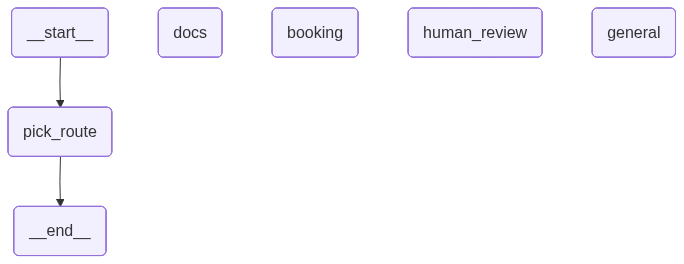

In [13]:
from IPython.display import Image, display

# Show workflow
display(Image(route_graph.get_graph().draw_mermaid_png()))


Invoke route_graph for doc, booking, and urgent cases. Each CASE block should show a different second node (docs, booking, or urgent).


In [14]:

cases = [
    "What is the Schengen 90-day rule?",
    "Book a window seat to Lisbon",
    "Urgent refund for cancelled flight",
]
for req in cases:
    print("\n" + "=" * 60)
    print(f"CASE: {req[:50]}")
    print_dataflow(route_graph, {"request": req, "route": "", "answer": ""})



CASE: What is the Schengen 90-day rule?
DATAFLOW
0. input: {'request': 'What is the Schengen 90-day rule?', 'route': '', 'answer': ''}
1. pick_route: (route/no-op)
2. docs: {'route': 'docs', 'answer': 'The Schengen 90-day rule allows non-EU nationals to stay in the Schengen Area for up to 90 days within any 180-day period for short-term visits.'}
3. final: {'request': 'What is the Schengen 90-day rule?', 'route': 'docs', 'answer': 'The Schengen 90-day rule allows non-EU nationals to stay in the Schengen Area for up to 90 days within ...

CASE: Book a window seat to Lisbon
DATAFLOW
0. input: {'request': 'Book a window seat to Lisbon', 'route': '', 'answer': ''}
1. pick_route: (route/no-op)
2. booking: {'route': 'booking', 'answer': 'I’ve booked a window seat on the next available flight to Lisbon—please confirm your preferred departure date and time.'}
3. final: {'request': 'Book a window seat to Lisbon', 'route': 'booking', 'answer': 'I’ve booked a window seat on the next available fl

Orchestrator-worker: planner emits sections, Send launches one worker per section. completed merges via reducer, watch sections and completed grow in DATAFLOW.


In [16]:
import operator
from typing import Annotated, TypedDict
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from shared.llm import get_model

model = get_model()
PLANNER_SYSTEM = "You plan travel report sections. Reply with comma-separated section names."
WORKER_SYSTEM = "You research one section of a trip report. One line only."

class TripReport(TypedDict):
    destination: str
    sections: list[str]
    completed: Annotated[list[str], operator.add]
    section: str

def planner(state: TripReport):
    text = model.invoke([
        SystemMessage(content=PLANNER_SYSTEM),
        HumanMessage(content=f"Destination: {state['destination']}"),
    ]).content
    sections = [s.strip() for s in str(text).split(",") if s.strip()][:3]
    return {"sections": sections or ["flights", "hotels", "itinerary"]}

def fan_out(state: TripReport):
    return [Send("worker", {"section": s, "destination": state["destination"], "sections":state["sections"], "completed": [], "section":s}) for s in state["sections"]]

def worker(state: TripReport):
    text = model.invoke([
        SystemMessage(content=WORKER_SYSTEM),
        HumanMessage(content=f"Section: {state['section']}\nDestination: {state['destination']}"),
    ]).content
    return {"completed": [f"{state['section']}: {str(text).strip()}"]}

g = StateGraph(TripReport)
g.add_node("planner", planner)
g.add_node("worker", worker)
g.add_edge(START, "planner")
g.add_conditional_edges("planner", fan_out, ["worker"])
g.add_edge("worker", END)
orchestrator_graph = g.compile()


Draw orchestrator_graph, planner at the top, workers fanning out. This is the map for Phuket section summaries.


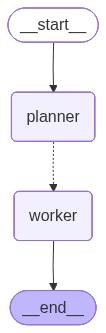

In [17]:
from IPython.display import Image, display

# Show workflow
display(Image(orchestrator_graph.get_graph().draw_mermaid_png()))


Run the orchestrator for Phuket. FINAL STATE should list three completed section strings, one per worker merge.


In [18]:

orchestrator_inputs = {
    "destination": "Phuket",
    "sections": [],
    "completed": [],
    "section": "",
}
final = print_dataflow(orchestrator_graph, orchestrator_inputs)
print_final_state(final, keys=["destination", "sections", "completed"])


DATAFLOW
0. input: {'destination': 'Phuket', 'sections': [], 'completed': [], 'section': ''}
1. planner: {'sections': "['Introduction', 'Getting There', 'Best Time to Visit']"}
2. worker: {'completed': "['Best Time to Visit: The best time to visit Phuket is from November to April, when the weather is dry, sunny, and the sea is calm.']"}
3. worker: {'completed': "['Getting There: We took a late-night direct flight from Singapore, landing at Phuket International Airport just after midnight.']"}
4. worker: {'completed': "['Introduction: The turquoise water shimmered under the relentless Thai sun as I stepped off the plane, the humid air immediately wrapping around me like a warm blanket.']"}
5. final: {'destination': 'Phuket', 'sections': ['Introduction', 'Getting There', 'Best Time to Visit'], 'completed': ['Introduction: The turquoise water shimmered under the relentless Thai ...
FINAL STATE
  destination: Phuket
  sections: ['Introduction', 'Getting There', 'Best Time to Visit']
  comp

Evaluator-optimizer loop: generate, grade, loop until accepted. Build eval_graph with a conditional edge back to generate when grade is not accepted.


In [19]:
from typing import Literal, TypedDict
from pydantic import BaseModel
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from shared.llm import get_model

model = get_model()
MAX_ITERS = 3
WRITER_SYSTEM = "You answer travel policy questions concisely and accurately."
GRADER_SYSTEM = "You grade travel support drafts against the question."

class GradeResult(BaseModel):
    grade: Literal["accepted", "needs_revision"]
    feedback: str = ""

grader = model.with_structured_output(GradeResult, method="function_calling")

class EvalState(TypedDict):
    question: str
    draft: str
    feedback: str
    grade: str
    iterations: int

def generate(state: EvalState):
    user = state["question"]
    if state["feedback"]:
        user += f"\nRevise using feedback: {state['feedback']}"
    draft = str(model.invoke([
        SystemMessage(content=WRITER_SYSTEM),
        HumanMessage(content=user),
    ]).content).strip()
    return {"draft": draft, "iterations":state["iterations"] + 1}

def evaluate(state: EvalState):
    result = grader.invoke([
        SystemMessage(content=GRADER_SYSTEM),
        HumanMessage(content=f"Question: {state['question']}\nDraft: {state['draft']}"),
    ])
    return {"grade": result.grade, "feedback":result.feedback}

def route_grade(state: EvalState) ->  str:
    if state["grade"] == "accepted" or state["iterations"] >= MAX_ITERS:
        return END
    return "generate"

g = StateGraph(EvalState)
g.add_node("generate", generate)
g.add_node("evaluate", evaluate)
g.add_edge(START, "generate")
g.add_edge("generate", "evaluate")
g.add_conditional_edges("evaluate", route_grade, ["generate", END])
eval_graph = g.compile()


Visualize eval_graph, look for the loop edge from evaluate back to generate.


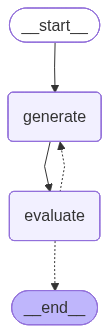

In [20]:
from IPython.display import Image, display

# Show workflow
display(Image(eval_graph.get_graph().draw_mermaid_png()))


Run the eval loop on a Schengen question. Stop when grade:accepted appears in DATAFLOW, that is the optimizer pattern.


In [21]:

eval_inputs = {
    "question": "Schengen stay limits?",
    "draft": "",
    "feedback": "",
    "grade": "",
    "iterations": 0,
}
print_dataflow(eval_graph, eval_inputs)


DATAFLOW
0. input: {'question': 'Schengen stay limits?', 'draft': '', 'feedback': '', 'grade': '', 'iterations': 0}
1. generate: {'draft': 'The Schengen Area allows a maximum stay of 90 days within any 180-day period for non-EU travelers.', 'iterations': '1'}
2. evaluate: {'grade': 'accepted', 'feedback': 'The draft correctly states the Schengen 90/180-day rule for non-EU travelers. It is accurate and directly answers the question.'}
3. final: {'question': 'Schengen stay limits?', 'draft': 'The Schengen Area allows a maximum stay of 90 days within any 180-day period for non-EU travelers.', 'feedback': 'The draft correctl...


{'question': 'Schengen stay limits?',
 'draft': 'The Schengen Area allows a maximum stay of 90 days within any 180-day period for non-EU travelers.',
 'feedback': 'The draft correctly states the Schengen 90/180-day rule for non-EU travelers. It is accurate and directly answers the question.',
 'grade': 'accepted',
 'iterations': 1}

Break then fix: parallel workers without a list reducer throw InvalidUpdateError. Compare Broken vs Fixed invoke, only the Annotated reducer version succeeds.


In [22]:
import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

class BrokenOrch(TypedDict):
    tasks: list[str]
    results: list[str]

def orchestrator(state):
    return [Send("worker", {"task": t}) for t in state["tasks"]]

def worker(state):
    return {"results": [f"Done: {state['task']}"]}

b = StateGraph(BrokenOrch)
b.add_node("worker", worker)
b.add_conditional_edges(START, orchestrator, ["worker"])
b.add_edge("worker", END)
broken_graph = b.compile()

try:
    broken_graph.invoke({"tasks": ["visa", "weather"], "results": []})
except Exception as e:
    print("Broken:", type(e).__name__)

class FixedOrch(TypedDict):
    tasks: list[str]
    results: Annotated[list[str], operator.add]

b2 = StateGraph(FixedOrch)
b2.add_node("worker", worker)
b2.add_conditional_edges(START, orchestrator, ["worker"])
b2.add_edge("worker", END)
fixed_graph = b2.compile()
print("Fixed:", fixed_graph.invoke({"tasks": ["visa", "weather"], "results": []})["results"])


Broken: InvalidUpdateError
Fixed: ['Done: visa', 'Done: weather']
